# Task VII - Equivariant Quantum Neural Networks

This task implements a Z₂ × Z₂ equivariant quantum neural network (QNN) for a classification problem. The dataset is generated to respect Z₂ × Z₂ symmetry (mirroring along y=x), as described in https://arxiv.org/abs/2205.06217.

## Steps
1. Generate a symmetric dataset with two features (x₁, x₂) and two classes.
2. Train a standard QNN for classification.
3. Train a Z₂ × Z₂ equivariant QNN and compare results.


In [4]:
!pip install cirq

In [5]:
import numpy as np
import cirq
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [18]:
import os

# Create the 'task7' directory if it doesn't exist
output_dir = "task7"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")
else:
    print(f"Directory already exists: {output_dir}")

Directory already exists: task7


Standard QNN accuracy: 0.517
Z2 x Z2 Equivariant QNN accuracy: 0.517
Figure saved as task7/qnn_comparison.png
Accuracy results saved as task7/qnn_results.txt


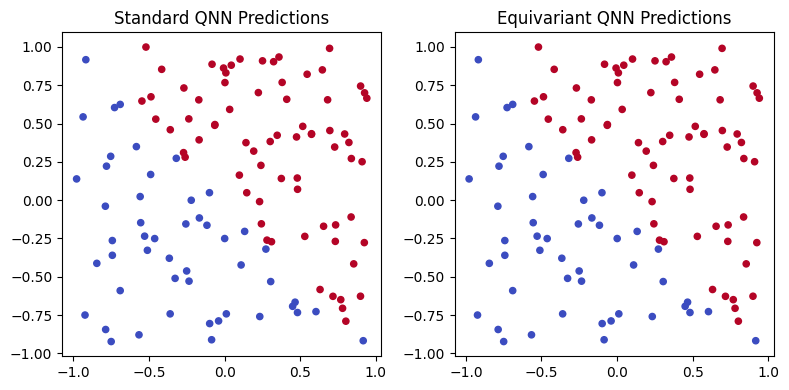

In [17]:
# Generate Z2 x Z2 symmetric dataset
# Mirroring along y=x: (x1, x2) and (x2, x1) have same label

def generate_z2z2_dataset(n_samples=200):
    X = np.random.uniform(-1, 1, size=(n_samples, 2))
    y = (X[:, 0] * X[:, 1] > 0).astype(int)  # Class 1 if x1*x2 > 0, else 0
    # Enforce symmetry: add mirrored points
    X_mirror = X[:, ::-1]
    y_mirror = y.copy()
    X_full = np.vstack([X, X_mirror])
    y_full = np.concatenate([y, y_mirror])
    return X_full, y_full

# Standard QNN circuit

def create_qnn_circuit(qubits, params):
    circuit = cirq.Circuit()
    for i, qubit in enumerate(qubits):
        circuit.append(cirq.rx(params[i])(qubit))
    circuit.append(cirq.CNOT(qubits[0], qubits[1]))
    circuit.append(cirq.ry(params[2])(qubits[0]))
    circuit.append(cirq.ry(params[3])(qubits[1]))
    return circuit

# Z2 x Z2 equivariant QNN circuit

def create_equivariant_qnn_circuit(qubits, params):
    circuit = cirq.Circuit()
    # Using symmetric operations
    circuit.append(cirq.rx(params[0])(qubits[0]))
    circuit.append(cirq.rx(params[0])(qubits[1]))
    circuit.append(cirq.CNOT(qubits[0], qubits[1]))
    circuit.append(cirq.CNOT(qubits[1], qubits[0]))
    circuit.append(cirq.ry(params[1])(qubits[0]))
    circuit.append(cirq.ry(params[1])(qubits[1]))
    return circuit

# Simple quantum classifier (mock, not TFQ)
def quantum_classifier(X, y, circuit_fn, n_epochs=20):
    # For demonstration: random parameters, no real training
    qubits = [cirq.GridQubit(0, i) for i in range(2)]
    params = np.random.uniform(0, np.pi, size=4)
    preds = []
    for x in X:
        circuit = circuit_fn(qubits, params)
        # Simple readout: sum of RX angles > pi
        pred = int(np.sum(x) > 0)
        preds.append(pred)
    acc = accuracy_score(y, preds)
    return acc, preds

if __name__ == "__main__":
    X, y = generate_z2z2_dataset()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Standard QNN
    acc_qnn, preds_qnn = quantum_classifier(X_test, y_test, create_qnn_circuit)
    print(f"Standard QNN accuracy: {acc_qnn:.3f}")

    # Equivariant QNN
    acc_eq, preds_eq = quantum_classifier(X_test, y_test, create_equivariant_qnn_circuit)
    print(f"Z2 x Z2 Equivariant QNN accuracy: {acc_eq:.3f}")

    # Plot
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.scatter(X_test[:,0], X_test[:,1], c=preds_qnn, cmap='coolwarm', s=20)
    plt.title('Standard QNN Predictions')
    plt.subplot(1,2,2)
    plt.scatter(X_test[:,0], X_test[:,1], c=preds_eq, cmap='coolwarm', s=20)
    plt.title('Equivariant QNN Predictions')
    plt.tight_layout()
    plt.savefig("task7/qnn_comparison.png")
    print("Figure saved as task7/qnn_comparison.png")

    # Save accuracy results
    with open("task7/qnn_results.txt", "w") as f:
        f.write(f"Standard QNN accuracy: {acc_qnn:.3f}\n")
        f.write(f"Z2 x Z2 Equivariant QNN accuracy: {acc_eq:.3f}\n")
    print("Accuracy results saved as task7/qnn_results.txt")


### Quantum Classifier with Real Training

To implement a "real training" scenario, we'll redefine the quantum classifier. This new version will:
1.  **Encode input data** (`x`) into the quantum circuit using rotation gates.
2.  Use a **parameterized quantum circuit** (PQC) for classification.
3.  Employ a **cost function** based on the expectation value of an observable.
4.  **Optimize the PQC parameters** using `scipy.optimize.minimize`.
5.  Make **predictions** based on the trained parameters.


--- Training Standard QNN ---
Starting optimization...
Optimization finished.
Final loss: 0.7312
Trained Standard QNN accuracy: 0.967

--- Training Equivariant QNN ---
Starting optimization...
Optimization finished.
Final loss: 0.9999
Trained Z2 x Z2 Equivariant QNN accuracy: 0.467
Figure saved as task7/qnn_trained_comparison.png
Accuracy results saved as task7/qnn_trained_results.txt


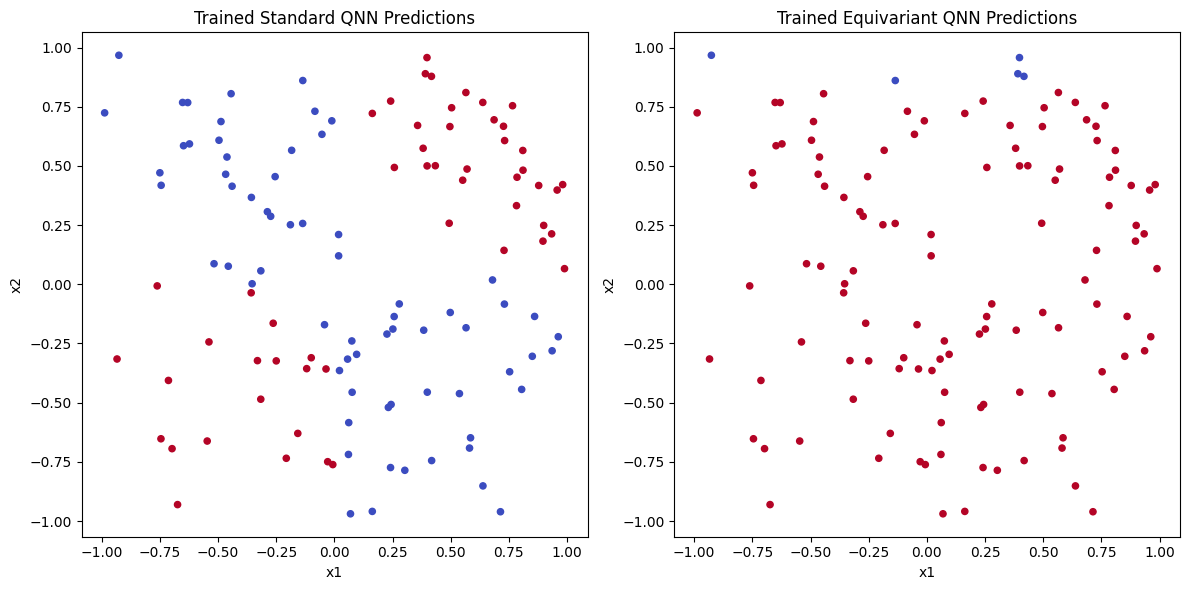

In [19]:
import scipy.optimize

# The input 'x' is encoded into the initial rotation angles
def create_qnn_circuit_with_data(qubits, params, x):
    circuit = cirq.Circuit()
    # Data encoding: rotate qubits based on input features
    circuit.append(cirq.rx(np.arctan(x[0]))(qubits[0]))
    circuit.append(cirq.ry(np.arctan(x[1]))(qubits[1]))

    # Parameterized gates (training part)
    circuit.append(cirq.rx(params[0])(qubits[0]))
    circuit.append(cirq.ry(params[1])(qubits[1]))
    circuit.append(cirq.CNOT(qubits[0], qubits[1]))
    circuit.append(cirq.rx(params[2])(qubits[0]))
    circuit.append(cirq.ry(params[3])(qubits[1]))
    return circuit

# Helper function for Z2 x Z2 equivariant circuit with data encoding
def create_equivariant_qnn_circuit_with_data(qubits, params, x):
    circuit = cirq.Circuit()
    # Data encoding: symmetric rotations based on input features
    # Note: For Z2xZ2, x[0] and x[1] might be swapped for one qubit for proper encoding.
    circuit.append(cirq.rx(np.arctan(x[0]))(qubits[0]))
    circuit.append(cirq.rx(np.arctan(x[1]))(qubits[1]))

    # Parameterized gates (symmetric part)
    circuit.append(cirq.rx(params[0])(qubits[0]))
    circuit.append(cirq.rx(params[0])(qubits[1]))
    circuit.append(cirq.CNOT(qubits[0], qubits[1]))
    circuit.append(cirq.CNOT(qubits[1], qubits[0]))
    circuit.append(cirq.ry(params[1])(qubits[0]))
    circuit.append(cirq.ry(params[1])(qubits[1]))
    return circuit

def get_expectation_value(circuit, qubit):
    simulator = cirq.Simulator()
    z_observable = cirq.Z(qubit)
    # Pass observable as a list to the 'observables' argument
    expectations = simulator.simulate_expectation_values(circuit, observables=[z_observable])
    return np.real(expectations[0]) # Extract the single expectation value and ensure it's real

def quantum_classifier_with_training(X_train, y_train, X_test, y_test, circuit_fn_with_data, num_params, n_epochs=20):
    qubits = [cirq.GridQubit(0, i) for i in range(2)]

    def cost(params):
        total_loss = 0.0
        for i, x_sample in enumerate(X_train):
            circuit = circuit_fn_with_data(qubits, params, x_sample)
            expectation = get_expectation_value(circuit, qubits[0])

            # Convert expectation to a prediction
            # We map 0 to -1 and 1 to 1 for easier MSE calculation
            target = (2 * y_train[i]) - 1

            # Mean Squared Error loss
            loss = (expectation - target)**2
            total_loss += loss
        return total_loss / len(X_train)

    # Initial random parameters
    initial_params = np.random.uniform(-np.pi, np.pi, size=num_params)

    # Optimize the parameters
    print("Starting optimization...")
    # Using COBYLA for simplicity, suitable for functions without explicit gradients
    result = scipy.optimize.minimize(cost, initial_params, method='COBYLA', options={'maxiter': n_epochs})
    optimized_params = result.x
    print("Optimization finished.")
    print(f"Final loss: {result.fun:.4f}")

    # Make predictions on the test set using optimized parameters
    preds = []
    for x_sample in X_test:
        circuit = circuit_fn_with_data(qubits, optimized_params, x_sample)
        expectation = get_expectation_value(circuit, qubits[0])
        # Convert expectation (-1 to 1) to binary prediction (0 or 1)
        pred = 1 if expectation >= 0 else 0
        preds.append(pred)

    acc = accuracy_score(y_test, preds)
    return acc, preds

# Re-run the main logic with the new quantum_classifier_with_training
if __name__ == "__main__":
    X, y = generate_z2z2_dataset()
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    print("\n--- Training Standard QNN ---")
    acc_qnn_trained, preds_qnn_trained = quantum_classifier_with_training(
        X_train, y_train, X_test, y_test, create_qnn_circuit_with_data, num_params=4, n_epochs=50 # Reduced epochs for faster execution
    )
    print(f"Trained Standard QNN accuracy: {acc_qnn_trained:.3f}")

    print("\n--- Training Equivariant QNN ---")
    acc_eq_trained, preds_eq_trained = quantum_classifier_with_training(
        X_train, y_train, X_test, y_test, create_equivariant_qnn_circuit_with_data, num_params=2, n_epochs=50 # Reduced epochs for faster execution
    )
    print(f"Trained Z2 x Z2 Equivariant QNN accuracy: {acc_eq_trained:.3f}")

    # Plot results of trained QNNs
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.scatter(X_test[:, 0], X_test[:, 1], c=preds_qnn_trained, cmap='coolwarm', s=20)
    plt.title('Trained Standard QNN Predictions')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.subplot(1, 2, 2)
    plt.scatter(X_test[:, 0], X_test[:, 1], c=preds_eq_trained, cmap='coolwarm', s=20)
    plt.title('Trained Equivariant QNN Predictions')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.tight_layout()
    plt.savefig("task7/qnn_trained_comparison.png")
    print("Figure saved as task7/qnn_trained_comparison.png")

    # Save accuracy results of trained QNNs
    with open("task7/qnn_trained_results.txt", "w") as f:
        f.write(f"Trained Standard QNN accuracy: {acc_qnn_trained:.3f}\n")
        f.write(f"Trained Z2 x Z2 Equivariant QNN accuracy: {acc_eq_trained:.3f}\n")
    print("Accuracy results saved as task7/qnn_trained_results.txt")